In [4]:
import rasterio
from rasterio.windows import Window
import numpy as np
import joblib

In [5]:

from rasterio.warp import reproject, Resampling
from rasterio.enums import Resampling as ResampleEnums
from rasterio.io import MemoryFile
import os
from rasterio.warp import calculate_default_transform, reproject, Resampling


In [3]:


rasters = [
    r"C:\Users\HP\Desktop\Academic Resrearch Work\Hybrid_Power\Codes\Processed\Dist_to_railway_reprojected_resampled.tif",
    r"C:\Users\HP\Desktop\Academic Resrearch Work\Hybrid_Power\Codes\Processed\Dist_to_road_reprojected_resampled.tif",
    r"C:\Users\HP\Desktop\Academic Resrearch Work\Hybrid_Power\Codes\Processed\Dist_to_tyranss_reprojected_resampled.tif",
    r"C:\Users\HP\Desktop\Academic Resrearch Work\Hybrid_Power\Codes\Processed\Wind_Speed_Nigeria_reprojected_resampled.tif",
    r"C:\Users\HP\Desktop\Academic Resrearch Work\Hybrid_Power\Codes\Processed\Elevation_Nigeria_reprojected_resampled.tif",
    r"C:\Users\HP\Desktop\Academic Resrearch Work\Hybrid_Power\Codes\Processed\Nigeria_GHI_reprojected_resampled.tif",
    r"C:\Users\HP\Desktop\Academic Resrearch Work\Hybrid_Power\Codes\Processed\LULC_Nigeria_reprojected_resampled.tif"
]

output_path = r"C:\Users\HP\Desktop\Academic Resrearch Work\Hybrid_Power\Codes\Processed\composite_image_LZW_fixed.tif"

# Open reference raster
with rasterio.open(rasters[0]) as ref:
    ref_meta = ref.meta.copy()
    ref_transform = ref.transform
    ref_crs = ref.crs
    ref_width = ref.width
    ref_height = ref.height

    ref_meta.update({
        "count": len(rasters),
        "dtype": "float32",
        "compress": "LZW",
        "BIGTIFF": "YES"
    })

    with rasterio.open(output_path, "w", **ref_meta) as dst:
        for idx, raster in enumerate(rasters, start=1):
            with rasterio.open(raster) as src:
                if (src.width != ref_width) or (src.height != ref_height) or (src.transform != ref_transform):
                    print(f"⚠ Aligning raster {idx}: {raster}")
                    # Process in chunks (matching ref windows)
                    for ji, window in ref.block_windows(1):
                        src_data = np.empty((window.height, window.width), dtype="float32")
                        reproject(
                            source=rasterio.band(src, 1),
                            destination=src_data,
                            src_transform=src.transform,
                            src_crs=src.crs,
                            dst_transform=ref_transform,
                            dst_crs=ref_crs,
                            resampling=Resampling.nearest,
                            dst_window=window
                        )
                        dst.write(src_data, idx, window=window)
                else:
                    print(f"✅ Already aligned: {raster}")
                    for ji, window in src.block_windows(1):
                        data = src.read(1, window=window).astype("float32")
                        dst.write(data, idx, window=window)

print(f"🎯 Composite image saved at: {output_path}")


✅ Already aligned: C:\Users\HP\Desktop\Academic Resrearch Work\Hybrid_Power\Codes\Processed\Dist_to_railway_reprojected_resampled.tif
✅ Already aligned: C:\Users\HP\Desktop\Academic Resrearch Work\Hybrid_Power\Codes\Processed\Dist_to_road_reprojected_resampled.tif
✅ Already aligned: C:\Users\HP\Desktop\Academic Resrearch Work\Hybrid_Power\Codes\Processed\Dist_to_tyranss_reprojected_resampled.tif
⚠ Aligning raster 4: C:\Users\HP\Desktop\Academic Resrearch Work\Hybrid_Power\Codes\Processed\Wind_Speed_Nigeria_reprojected_resampled.tif
⚠ Aligning raster 5: C:\Users\HP\Desktop\Academic Resrearch Work\Hybrid_Power\Codes\Processed\Elevation_Nigeria_reprojected_resampled.tif
⚠ Aligning raster 6: C:\Users\HP\Desktop\Academic Resrearch Work\Hybrid_Power\Codes\Processed\Nigeria_GHI_reprojected_resampled.tif
⚠ Aligning raster 7: C:\Users\HP\Desktop\Academic Resrearch Work\Hybrid_Power\Codes\Processed\LULC_Nigeria_reprojected_resampled.tif
🎯 Composite image saved at: C:\Users\HP\Desktop\Academic Re

In [ ]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import joblib

# Paths
composite_path = r"C:\Users\HP\Desktop\Academic Resrearch Work\Hybrid_Power\Codes\Hybrid_Energy_1.tif"
model_path = r"C:\Users\HP\Desktop\Academic Resrearch Work\Hybrid_Power\Codes\suitability_model.pkl"

# Load model
model = joblib.load(model_path)

# Read raster
with rasterio.open(composite_path) as src:
    profile = src.profile  # to keep geospatial info later
    data = src.read()  # shape: (bands, rows, cols)

# Reshape to (pixels, bands)
bands, rows, cols = data.shape
data_reshaped = data.reshape(bands, rows * cols).T  # now (pixels, bands)

# Predict
predictions = model.predict(data_reshaped)

# Reshape back to raster shape
prediction_raster = predictions.reshape(rows, cols)

# Plot prediction raster
plt.imshow(prediction_raster, cmap='viridis')
plt.colorbar(label='Suitability')
plt.title("Suitability Prediction Map")
plt.show()

# Save prediction raster with geospatial info
prediction_profile = profile.copy()
prediction_profile.update(dtype=rasterio.float32, count=1)

output_path = r"C:\Users\HP\Desktop\suitability_prediction1.tif"
with rasterio.open(output_path, 'w', **prediction_profile) as dst:
    dst.write(prediction_raster.astype(rasterio.float32), 1)

print(f"Prediction map saved at {output_path}")


In [2]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import joblib
from rasterio.plot import show

# Paths
composite_path = r"C:\Users\HP\Desktop\Academic Resrearch Work\Hybrid_Power\Codes\Hybrid_Energy_1.tif"
model_path = r"C:\Users\HP\Desktop\Academic Resrearch Work\Hybrid_Power\Codes\suitability_model.pkl"
output_path = r"C:\Users\HP\Desktop\Academic Resrearch Work\Hybrid_Power\Codes\suitability_prediction1.tif"

# Load model
model = joblib.load(model_path)

# Read raster & profile
with rasterio.open(composite_path) as src:
    profile = src.profile  # keep CRS, transform, resolution
    data = src.read()      # shape: (bands, rows, cols)
    nodata_val = src.nodata

# Create mask for nodata pixels (based on first band)
if nodata_val is not None:
    mask = data[0] == nodata_val
else:
    mask = np.zeros((data.shape[1], data.shape[2]), dtype=bool)

# Reshape to (pixels, bands)
bands, rows, cols = data.shape
data_reshaped = data.reshape(bands, rows * cols).T  # now (pixels, bands)

# Apply mask to prediction array
if nodata_val is not None:
    data_reshaped[mask.flatten()] = np.nan  # avoid predicting on NoData

# Predict only where valid
predictions = np.full((rows * cols,), -1, dtype=np.int8)  # default -1 for nodata
valid_idx = ~np.isnan(data_reshaped).any(axis=1)
predictions[valid_idx] = model.predict(data_reshaped[valid_idx]).astype(np.int8)

# Reshape back to raster
prediction_raster = predictions.reshape(rows, cols)

# Save prediction raster with geospatial info
prediction_profile = profile.copy()
prediction_profile.update(dtype=rasterio.int8, count=1, nodata=-1)

with rasterio.open(output_path, 'w', **prediction_profile) as dst:
    dst.write(prediction_raster, 1)

print(f"Prediction map saved at {output_path}")

# Plot in real-world coordinates
with rasterio.open(output_path) as pred_src:
    fig, ax = plt.subplots(figsize=(10, 6))
    show(pred_src, ax=ax, cmap='viridis')
    ax.set_title("Suitability Prediction Map (Georeferenced)")
    plt.show()


c:\Users\HP\anaconda3\envs\New_Environment\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


MemoryError: Unable to allocate 745. MiB for an array with shape (97691853,) and data type int64

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import joblib
from rasterio.plot import show

c:\Users\HP\anaconda3\envs\New_Environment\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\HP\anaconda3\envs\New_Environment\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\HP\anaconda3\envs\New_Environment\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\HP\anaconda3\envs\New_Environment\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(
c:\Users\HP\anaconda3\envs\New_Environment\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have 

Prediction map saved at C:\Users\HP\Desktop\Academic Resrearch Work\Hybrid_Power\Codes\spatial_suitability_prediction2.tif


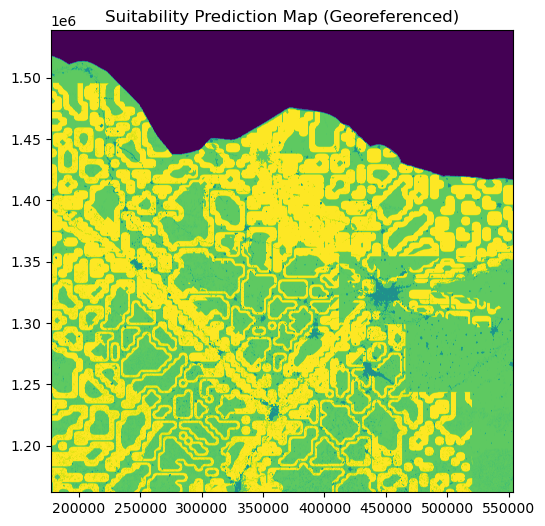

In [14]:


# Paths
composite_path = r"C:\Users\HP\Desktop\Academic Resrearch Work\Hybrid_Power\Codes\Hybrid_Energy_2.tif"
model_path = r"C:\Users\HP\Desktop\Academic Resrearch Work\Hybrid_Power\Codes\suitability_model_spatial.pkl"
output_path = r"C:\Users\HP\Desktop\Academic Resrearch Work\Hybrid_Power\Codes\spatial_suitability_prediction2.tif"

# Load model
model = joblib.load(model_path)

# Open raster & prepare output profile
with rasterio.open(composite_path) as src:
    profile = src.profile
    nodata_val = src.nodata
    rows, cols = src.height, src.width
    bands = src.count

prediction_profile = profile.copy()
prediction_profile.update(dtype=rasterio.int8, count=1, nodata=-1)

# Window (chunk) size — adjust based on your RAM
block_size = 512  

with rasterio.open(composite_path) as src, rasterio.open(output_path, "w", **prediction_profile) as dst:
    for y in range(0, rows, block_size):
        for x in range(0, cols, block_size):

            # Define window
            win_width = min(block_size, cols - x)
            win_height = min(block_size, rows - y)
            window = rasterio.windows.Window(x, y, win_width, win_height)

            # Read block
            data_block = src.read(window=window)  # shape: (bands, win_h, win_w)

            # Mask NoData
            if nodata_val is not None:
                mask = data_block[0] == nodata_val
            else:
                mask = np.zeros((win_height, win_width), dtype=bool)

            # Reshape for prediction
            reshaped = data_block.reshape(bands, win_height * win_width).T

            # Prepare output block (default -1)
            preds_block = np.full((win_height * win_width,), -1, dtype=np.int8)

            # Predict where valid
            valid_idx = ~np.isnan(reshaped).any(axis=1) & ~mask.flatten()
            if np.any(valid_idx):
                preds_block[valid_idx] = model.predict(reshaped[valid_idx]).astype(np.int8)

            # Reshape back & write
            preds_block = preds_block.reshape(win_height, win_width)
            dst.write(preds_block, 1, window=window)

print(f"Prediction map saved at {output_path}")

# Plot the saved prediction
with rasterio.open(output_path) as pred_src:
    fig, ax = plt.subplots(figsize=(10, 6))
    show(pred_src, ax=ax, cmap='viridis')
    ax.set_title("Suitability Prediction Map (Georeferenced)")
    plt.show()
